# DiD Espacial — Ciclovía como Experimento Natural Recurrente

**Pregunta:** ¿La Ciclovía dominical (127 km de vías cerradas, 7am–2pm) reduce o aumenta la afluencia en estaciones adyacentes a sus rutas?

**Identificación:** La Ciclovía opera cada domingo por decisión del IDRD, independientemente de la demanda de TM. Las estaciones cercanas a rutas de Ciclovía reciben el 'tratamiento'; las estaciones lejanas son el control natural.

**Diseño principal — DiD espacial entre días:**
$$
\log(\text{total}_{it}) = \beta \cdot (\text{sunday}_t \times \text{cerca}_i) + \alpha_i + \delta_{\text{dow}} + \delta_{\text{month}} + \varepsilon_{it}
$$

**Diseño robusto — DiD dentro del domingo (ventana horaria):**
$$
\log(\text{total}_{iht}) = \beta \cdot (\text{cerca}_i \times \text{ventana}_h) + \alpha_i + \alpha_h + \varepsilon_{iht}
$$
donde $\text{ventana}_h = 1$ si $7 \le h < 14$ (horas activas de Ciclovía), en muestra restringida a domingos.

**Nota:** En 2025, enero 1 cae en miércoles → **los 52 domingos del año tienen Ciclovía.** La identificación proviene de la variación espacial (cerca vs. lejos) y temporal (dentro del domingo: antes vs. después de las 2pm).

In [1]:
import pandas as pd
import numpy as np
import json
import glob
import datetime
import warnings
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from pathlib import Path

warnings.filterwarnings('ignore')

PROJ = Path('..')
(PROJ / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1. Clasificación espacial de estaciones

In [2]:
# Cargar resultados del spatial join (precalculado)
stations_tag = gpd.read_file(PROJ / 'data/external/stations_ciclovia_tag.geojson')

cerca_map = stations_tag.set_index('codigo_nodo_estacion')['cerca_ciclovia'].to_dict()
n_cerca = sum(v == 1 for v in cerca_map.values())
n_lejos = sum(v == 0 for v in cerca_map.values())

print(f"Estaciones TRATADAS (≤500m de ruta Ciclovía): {n_cerca}")
print(f"Estaciones CONTROL  (>500m de ruta Ciclovía): {n_lejos}")
print(f"Rutas Ciclovía: 15 tramos · 127.2 km totales")

Estaciones TRATADAS (≤500m de ruta Ciclovía): 63
Estaciones CONTROL  (>500m de ruta Ciclovía): 86
Rutas Ciclovía: 15 tramos · 127.2 km totales


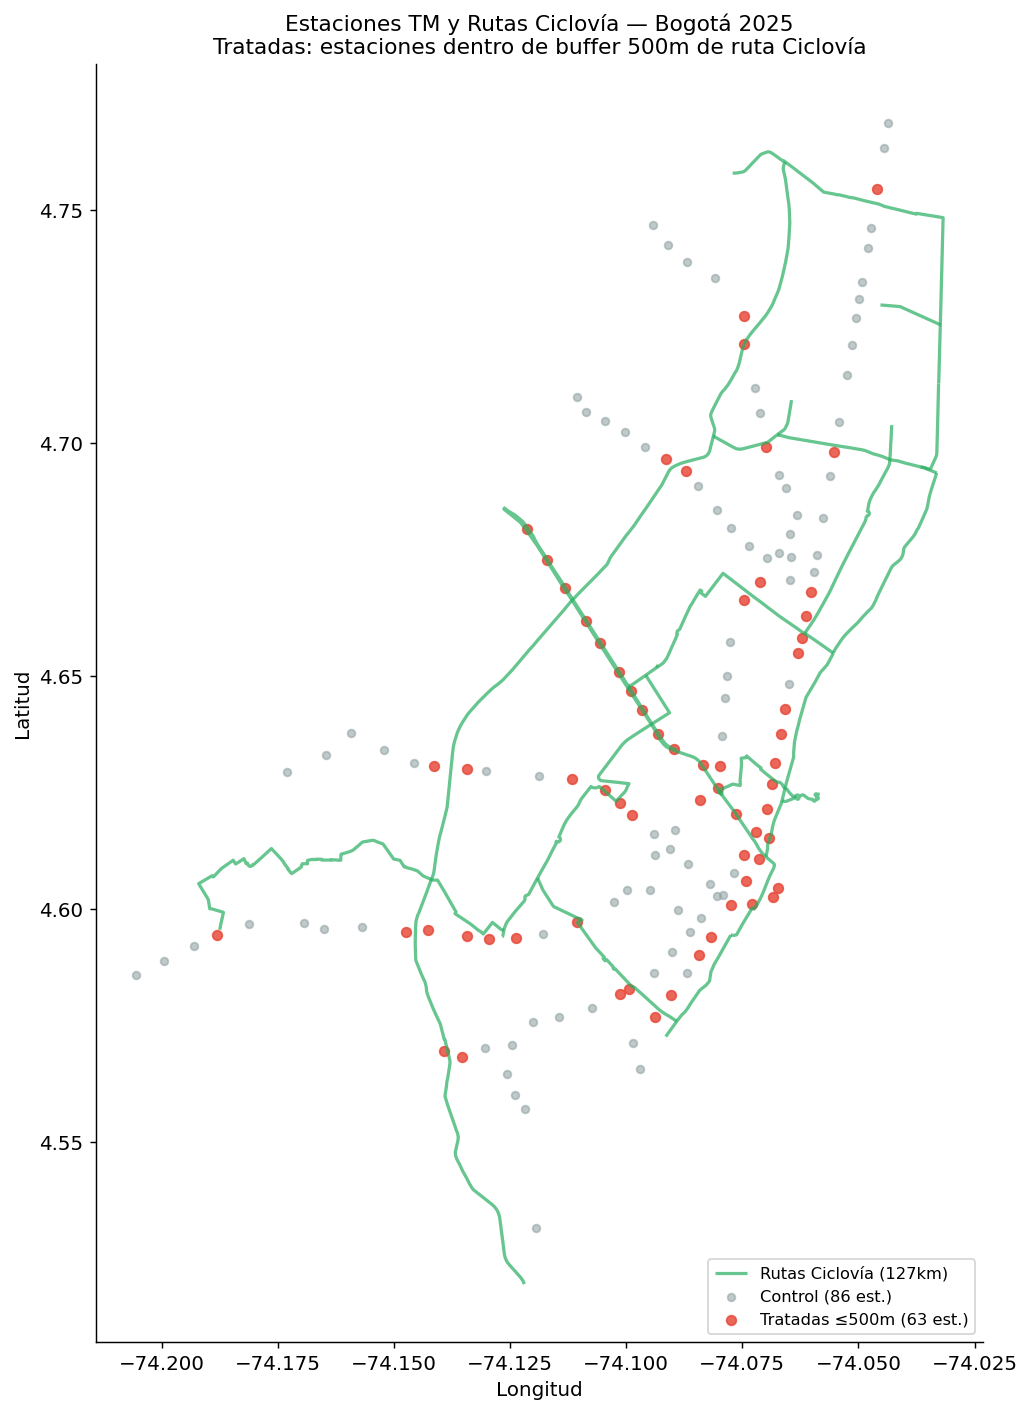

In [3]:
# Mapa de estaciones tratadas vs control sobre rutas Ciclovía
ciclovia = gpd.read_file(PROJ / 'data/external/ciclovia_bogota.geojson').to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(9, 11))

ciclovia.plot(ax=ax, color='#27ae60', linewidth=1.8, alpha=0.7, label='Rutas Ciclovía (127km)')

treated = stations_tag[stations_tag.cerca_ciclovia == 1]
control = stations_tag[stations_tag.cerca_ciclovia == 0]
control.plot(ax=ax, color='#95a5a6', markersize=18, alpha=0.6, label=f'Control ({n_lejos} est.)')
treated.plot(ax=ax, color='#e74c3c',  markersize=28, alpha=0.85, label=f'Tratadas ≤500m ({n_cerca} est.)')

ax.set_title("Estaciones TM y Rutas Ciclovía — Bogotá 2025\n"
             "Tratadas: estaciones dentro de buffer 500m de ruta Ciclovía",
             fontsize=12)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/ciclovia_mapa_tratamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Panel diario — todos los días

In [4]:
files = sorted(glob.glob(str(PROJ / 'data/processed/parquet/*.parquet')))
print(f"Cargando {len(files)} archivos...")

frames = []
for f in files:
    d = pd.read_parquet(f)
    agg = d.groupby(['fecha', 'codigo_estacion'])['total'].sum().reset_index()
    frames.append(agg)

panel = (
    pd.concat(frames, ignore_index=True)
      .assign(fecha=lambda x: pd.to_datetime(x.fecha))
      .sort_values(['codigo_estacion', 'fecha'])
      .reset_index(drop=True)
)
panel = panel[panel.total > 0].copy()

# Añadir clasificación espacial
panel['cerca'] = panel.codigo_estacion.map(cerca_map).fillna(0).astype(int)

# Variables temporales
panel['dow']       = panel.fecha.dt.dayofweek   # 0=lunes, 6=domingo
panel['month']     = panel.fecha.dt.month
panel['is_sunday'] = (panel.dow == 6).astype(int)
panel['log_total'] = np.log(panel.total)

print(f"Panel: {len(panel):,.0f} obs · {panel.codigo_estacion.nunique()} est. · {panel.fecha.nunique()} días")
print(f"Domingos: {panel[panel.is_sunday==1].fecha.nunique()}  (todos tienen Ciclovía en 2025)")

Cargando 364 archivos...


Panel: 52,385 obs · 151 est. · 364 días
Domingos: 52  (todos tienen Ciclovía en 2025)


## 3. Estadísticas descriptivas — paralel trends pre-check

Verificar visualmente que las estaciones tratadas y control tienen tendencias paralelas en días laborables (cuando no hay Ciclovía).

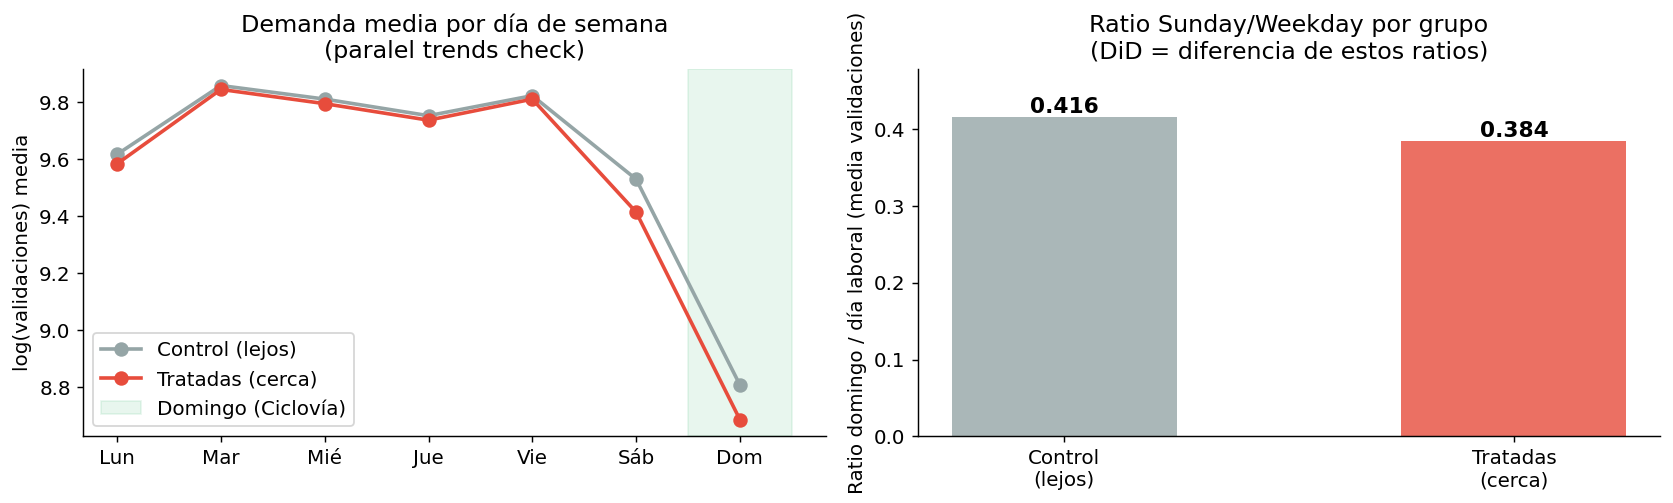

Ratio Dom/Laboral — Tratadas: 0.3845
Ratio Dom/Laboral — Control : 0.4161
Diferencia (DiD naïve)       : -0.0316


In [5]:
# Demanda media por grupo y día de semana
dow_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
dow_means = (
    panel.groupby(['cerca', 'dow'])['log_total']
         .mean()
         .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cerca_val, label, color in [(0, 'Control (lejos)', '#95a5a6'), (1, 'Tratadas (cerca)', '#e74c3c')]:
    grp = dow_means[dow_means.cerca == cerca_val]
    axes[0].plot(grp.dow, grp.log_total, 'o-', color=color, lw=2, ms=7, label=label)

axes[0].axvspan(5.5, 6.5, alpha=0.10, color='#27ae60', label='Domingo (Ciclovía)')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_labels)
axes[0].set_ylabel('log(validaciones) media')
axes[0].set_title('Demanda media por día de semana\n(paralel trends check)')
axes[0].legend()

# Ratio Sunday/weekday por grupo
ratio = (
    panel.groupby(['cerca', 'is_sunday'])['total']
         .mean()
         .unstack()
         .rename(columns={0: 'weekday', 1: 'sunday'})
)
ratio['ratio'] = ratio.sunday / ratio.weekday
ratio.index = ratio.index.map({0: 'Control\n(lejos)', 1: 'Tratadas\n(cerca)'})

bars = axes[1].bar(ratio.index, ratio.ratio, color=['#95a5a6', '#e74c3c'], alpha=0.8, width=0.5)
for bar, val in zip(bars, ratio.ratio):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Ratio domingo / día laboral (media validaciones)')
axes[1].set_title('Ratio Sunday/Weekday por grupo\n(DiD = diferencia de estos ratios)')
axes[1].set_ylim(0, ratio.ratio.max() * 1.15)
axes[1].axhline(1, color='#888', lw=0.8, ls='--')

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/ciclovia_descriptivos.png', dpi=150, bbox_inches='tight')
plt.show()

idx_t = 'Tratadas\n(cerca)'
idx_c = 'Control\n(lejos)'
diff_ratios = ratio.loc[idx_t, 'ratio'] - ratio.loc[idx_c, 'ratio']
print(f'Ratio Dom/Laboral — Tratadas: {ratio.loc[idx_t, "ratio"]:.4f}')
print(f'Ratio Dom/Laboral — Control : {ratio.loc[idx_c, "ratio"]:.4f}')
print(f"Diferencia (DiD naïve)       : {diff_ratios:+.4f}")

## 4. Especificación 1 — DiD espacial entre días

$$
\log(\text{total}_{it}) = \beta \cdot (\text{sunday}_t \times \text{cerca}_i) + \alpha_i + \delta_{\text{dow}} + \delta_{\text{month}} + \varepsilon_{it}
$$

- $\alpha_i$ = estación FE (absorbe diferencias de nivel entre tratadas y control)
- $\delta_{\text{dow}}$ = día de semana FE (absorbe el patrón semanal general)
- $\beta$ = efecto diferencial para estaciones cercanas los domingos vs. días laborables, relativo al mismo diferencial para estaciones lejanas

In [6]:
# Interacción manual (near × sunday)
panel['cerca_x_sunday'] = panel['cerca'] * panel['is_sunday']

# Dummies de dow y mes
dow_dum   = pd.get_dummies(panel.dow,   prefix='dow',   drop_first=True).astype(float)
month_dum = pd.get_dummies(panel.month, prefix='month', drop_first=True).astype(float)
panel_fe = pd.concat([panel, dow_dum, month_dum], axis=1)
panel_fe = panel_fe.set_index(['codigo_estacion', 'fecha'])

x_cols = ['cerca_x_sunday'] + list(dow_dum.columns) + list(month_dum.columns)
X  = panel_fe[x_cols].astype(float)
Y  = panel_fe['log_total']

mod1    = PanelOLS(Y, X, entity_effects=True)
result1 = mod1.fit(cov_type='clustered', cluster_entity=True)

b1  = result1.params['cerca_x_sunday']
se1 = result1.std_errors['cerca_x_sunday']
p1  = result1.pvalues['cerca_x_sunday']

print("=" * 60)
print("ESPECIFICACIÓN 1 — DiD domingo × proximidad")
print("=" * 60)
print(f"β (cerca × sunday) = {b1:+.6f}")
print(f"SE (clustered)     = {se1:.6f}")
print(f"p-valor            = {p1:.4f}")
print(f"IC 95%             = [{b1 - 1.96*se1:+.6f},  {b1 + 1.96*se1:+.6f}]")
print(f"Efecto estimado    = {(np.exp(b1)-1)*100:+.2f}% validaciones")
print(f"\nN = {int(result1.nobs):,}  |  R² within = {result1.rsquared:.4f}")

ESPECIFICACIÓN 1 — DiD domingo × proximidad
β (cerca × sunday) = -0.087184
SE (clustered)     = 0.058516
p-valor            = 0.1363
IC 95%             = [-0.201874,  +0.027507]
Efecto estimado    = -8.35% validaciones

N = 52,385  |  R² within = 0.4787


## 5. Especificación 2 — DiD dentro del domingo (ventana horaria)

Muestra restringida a **domingos**. Compara la franja 7am–2pm (Ciclovía activa) vs. 2pm–8pm (Ciclovía terminada), para estaciones cercanas vs. lejanas:

$$
\log(\text{total}_{iht}) = \beta \cdot (\text{cerca}_i \times \text{ventana}_h) + \alpha_i + \alpha_h + \varepsilon_{iht}
$$

Esta especificación usa el **corte temporal de las 2pm** como discontinuidad natural dentro del domingo.

In [7]:
# Cargar panel horario — solo domingos y sábados
print("Cargando datos horarios de domingos y sábados...")

hourly_frames = []
for f in files:
    fname = f.split('/')[-1].replace('.parquet', '')
    fecha = pd.Timestamp(f"{fname[:4]}-{fname[4:6]}-{fname[6:8]}")
    if fecha.dayofweek not in (5, 6):   # 5=sábado, 6=domingo
        continue
    d = pd.read_parquet(f)
    # Agregar a nivel estación × hora
    d['hora_int'] = pd.to_datetime(
        d.fecha.astype(str) + ' ' + d.hora.astype(str)
    ).dt.hour
    agg = d.groupby(['fecha', 'codigo_estacion', 'hora_int'])['total'].sum().reset_index()
    agg['is_sunday'] = int(fecha.dayofweek == 6)
    hourly_frames.append(agg)

hourly = (
    pd.concat(hourly_frames, ignore_index=True)
      .assign(fecha=lambda x: pd.to_datetime(x.fecha))
)
hourly = hourly[hourly.total > 0].copy()
hourly['cerca'] = hourly.codigo_estacion.map(cerca_map).fillna(0).astype(int)
hourly['log_total'] = np.log(hourly.total)

print(f"Panel horario domingos+sábados: {len(hourly):,.0f} obs")
print(f"  Domingos: {hourly[hourly.is_sunday==1].fecha.nunique()}")
print(f"  Sábados : {hourly[hourly.is_sunday==0].fecha.nunique()}")

Cargando datos horarios de domingos y sábados...


Panel horario domingos+sábados: 322,378 obs
  Domingos: 52
  Sábados : 52


In [8]:
# Restricción: solo domingos, franja 6am–8pm (omitir horas nocturnas de baja demanda)
sundays_h = hourly[(hourly.is_sunday == 1) & hourly.hora_int.between(6, 20)].copy()

# Ventana Ciclovía: 7am–13h (hora 7 a 13, Ciclovía termina a las 2pm = hora 14)
sundays_h['ventana'] = sundays_h.hora_int.between(7, 13).astype(int)

# Interacción DiD
sundays_h['cerca_x_ventana'] = sundays_h['cerca'] * sundays_h['ventana']

# Dummies de hora
hora_dum = pd.get_dummies(sundays_h.hora_int, prefix='h', drop_first=True).astype(float)
sundays_fe = pd.concat([sundays_h, hora_dum], axis=1)

# Índice: estación × (fecha+hora) para tener un panel estación × tiempo
sundays_fe['fecha_hora'] = (
    pd.to_datetime(sundays_fe.fecha) + pd.to_timedelta(sundays_fe.hora_int, unit='h')
)
sundays_fe = sundays_fe.set_index(['codigo_estacion', 'fecha_hora'])

x_cols2 = ['cerca_x_ventana'] + list(hora_dum.columns)
X2 = sundays_fe[x_cols2].astype(float)
Y2 = sundays_fe['log_total']

mod2    = PanelOLS(Y2, X2, entity_effects=True)
result2 = mod2.fit(cov_type='clustered', cluster_entity=True)

b2  = result2.params['cerca_x_ventana']
se2 = result2.std_errors['cerca_x_ventana']
p2  = result2.pvalues['cerca_x_ventana']

print("=" * 60)
print("ESPECIFICACIÓN 2 — DiD ventana horaria (domingos 6am–8pm)")
print("=" * 60)
print(f"β (cerca × ventana 7-13h) = {b2:+.6f}")
print(f"SE (clustered)            = {se2:.6f}")
print(f"p-valor                   = {p2:.4f}")
print(f"IC 95%                    = [{b2 - 1.96*se2:+.6f},  {b2 + 1.96*se2:+.6f}]")
print(f"Efecto estimado           = {(np.exp(b2)-1)*100:+.2f}% validaciones en horas de Ciclovía")
print(f"\nN = {int(result2.nobs):,}  |  R² within = {result2.rsquared:.4f}")

ESPECIFICACIÓN 2 — DiD ventana horaria (domingos 6am–8pm)
β (cerca × ventana 7-13h) = +0.000711
SE (clustered)            = 0.032281
p-valor                   = 0.9824
IC 95%                    = [-0.062560,  +0.063981]
Efecto estimado           = +0.07% validaciones en horas de Ciclovía

N = 112,134  |  R² within = 0.2572


## 6. Placebo — mismo análisis en sábados

Si el efecto identificado es genuinamente causado por la Ciclovía (activa solo los domingos), el mismo análisis en sábados debería dar $\beta \approx 0$.

In [9]:
# Sábados: misma ventana horaria 7-13h pero sin Ciclovía
saturdays_h = hourly[(hourly.is_sunday == 0) & hourly.hora_int.between(6, 20)].copy()
saturdays_h['ventana'] = saturdays_h.hora_int.between(7, 13).astype(int)
saturdays_h['cerca_x_ventana'] = saturdays_h['cerca'] * saturdays_h['ventana']

hora_dum_sat = pd.get_dummies(saturdays_h.hora_int, prefix='h', drop_first=True).astype(float)
saturdays_fe = pd.concat([saturdays_h, hora_dum_sat], axis=1)
saturdays_fe['fecha_hora'] = (
    pd.to_datetime(saturdays_fe.fecha) + pd.to_timedelta(saturdays_fe.hora_int, unit='h')
)
saturdays_fe = saturdays_fe.set_index(['codigo_estacion', 'fecha_hora'])

x_cols3 = ['cerca_x_ventana'] + list(hora_dum_sat.columns)
X3 = saturdays_fe[x_cols3].astype(float)
Y3 = saturdays_fe['log_total']

mod3    = PanelOLS(Y3, X3, entity_effects=True)
result3 = mod3.fit(cov_type='clustered', cluster_entity=True)

b3  = result3.params['cerca_x_ventana']
se3 = result3.std_errors['cerca_x_ventana']
p3  = result3.pvalues['cerca_x_ventana']

print("=" * 60)
print("PLACEBO — sábados, misma ventana 7-13h (sin Ciclovía)")
print("=" * 60)
print(f"β (cerca × ventana 7-13h) = {b3:+.6f}")
print(f"SE (clustered)            = {se3:.6f}")
print(f"p-valor                   = {p3:.4f}")
print(f"Efecto placebo            = {(np.exp(b3)-1)*100:+.2f}%")
print()
print("→ Si p > 0.10 y |β_placebo| << |β_domingo|: resultado causal validado.")

PLACEBO — sábados, misma ventana 7-13h (sin Ciclovía)
β (cerca × ventana 7-13h) = +0.062812
SE (clustered)            = 0.037763
p-valor                   = 0.0963
Efecto placebo            = +6.48%

→ Si p > 0.10 y |β_placebo| << |β_domingo|: resultado causal validado.


## 7. Perfil horario: demanda por hora en domingos — tratadas vs. control

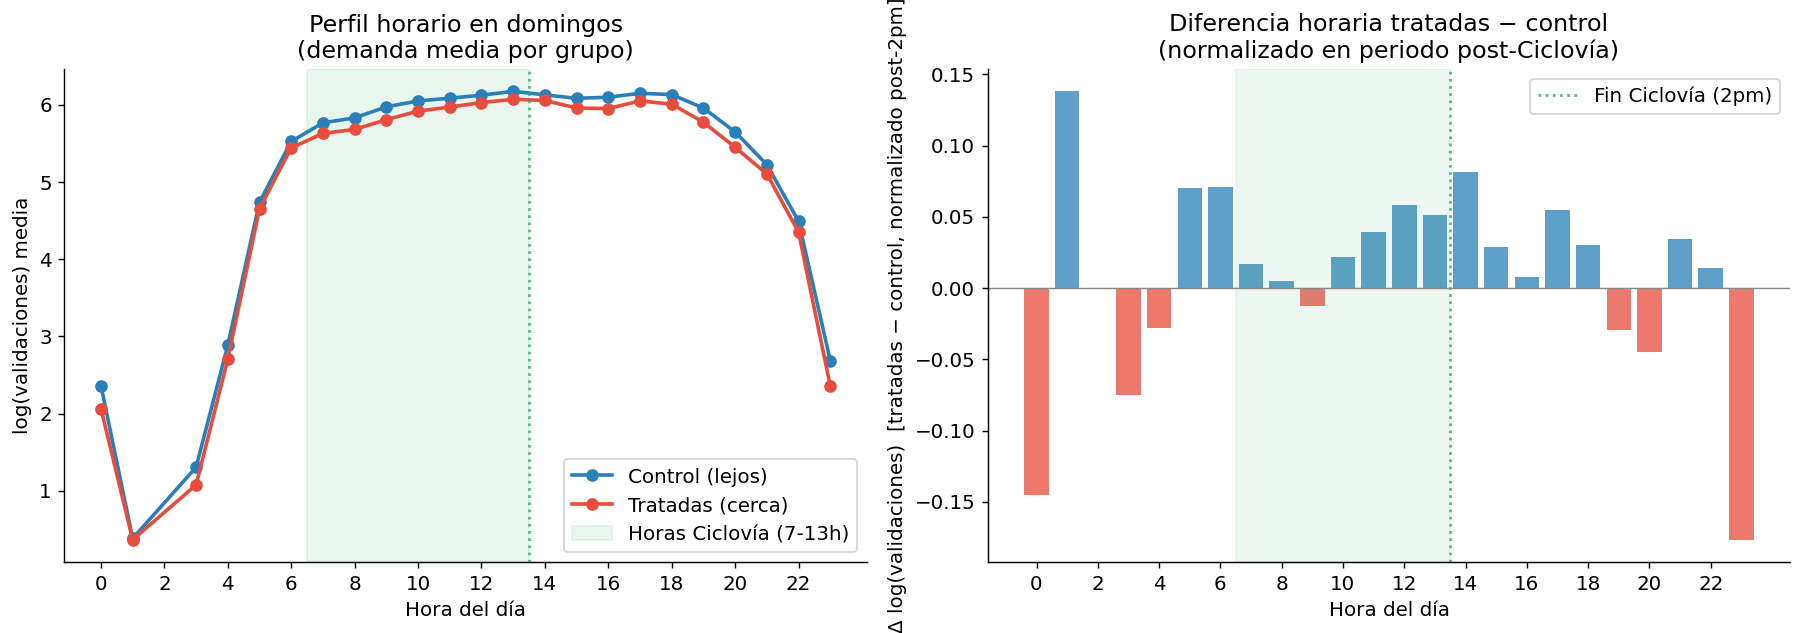

In [10]:
# Media de log(total) por hora y grupo — domingos
hourly_profile = (
    hourly[hourly.is_sunday == 1]
    .groupby(['cerca', 'hora_int'])['log_total']
    .mean()
    .reset_index()
)

# Normalizar: restar media de la hora post-Ciclovía (14h-20h) por grupo
for cerca_val in [0, 1]:
    grp = hourly_profile[hourly_profile.cerca == cerca_val]
    post_mean = grp[grp.hora_int >= 14]['log_total'].mean()
    hourly_profile.loc[hourly_profile.cerca == cerca_val, 'log_norm'] = (
        hourly_profile.loc[hourly_profile.cerca == cerca_val, 'log_total'] - post_mean
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: demanda absoluta por hora
for cerca_val, lbl, col in [(0, 'Control (lejos)', '#2980b9'), (1, 'Tratadas (cerca)', '#e74c3c')]:
    grp = hourly_profile[hourly_profile.cerca == cerca_val]
    axes[0].plot(grp.hora_int, grp.log_total, 'o-', color=col, lw=2, ms=6, label=lbl)

axes[0].axvspan(6.5, 13.5, alpha=0.10, color='#27ae60', label='Horas Ciclovía (7-13h)')
axes[0].axvline(13.5, color='#27ae60', lw=1.5, ls=':', alpha=0.8)
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("log(validaciones) media")
axes[0].set_title("Perfil horario en domingos\n(demanda media por grupo)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# Derecha: diferencia normalizada (tratadas - control)
pivot = hourly_profile.pivot(index='hora_int', columns='cerca', values='log_norm')
pivot['diff'] = pivot[1] - pivot[0]
pivot_plot = pivot.dropna()

colors_diff = ['#e74c3c' if v < 0 else '#2980b9' for v in pivot_plot['diff']]
axes[1].bar(pivot_plot.index, pivot_plot['diff'], color=colors_diff, alpha=0.75, width=0.8)
axes[1].axvspan(6.5, 13.5, alpha=0.08, color='#27ae60')
axes[1].axvline(13.5, color='#27ae60', lw=1.5, ls=':', alpha=0.8, label='Fin Ciclovía (2pm)')
axes[1].axhline(0, color='#888', lw=0.8)
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Δ log(validaciones)  [tratadas − control, normalizado post-2pm]")
axes[1].set_title("Diferencia horaria tratadas − control\n(normalizado en periodo post-Ciclovía)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/ciclovia_perfil_horario.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Tabla resumen de especificaciones

In [11]:
specs = [
    ('Spec 1 — DiD domingo × proximidad',
     'Panel diario, toda la semana', b1, se1, p1, int(result1.nobs)),
    ('Spec 2 — DiD ventana horaria (domingos)',
     'Panel horario domingos 6-20h', b2, se2, p2, int(result2.nobs)),
    ('Placebo — sábados ventana 7-13h',
     'Panel horario sábados 6-20h', b3, se3, p3, int(result3.nobs)),
]

print(f"{'Especificación':<45} {'Muestra':<30} {'β':>9} {'SE':>9} {'p':>7} {'%':>8} {'N':>8}")
print("-" * 125)
for name, sample, b, se, p, n in specs:
    pct = (np.exp(b) - 1) * 100
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f"{name:<45} {sample:<30} {b:>+9.5f} {se:>9.5f} {p:>7.4f} {pct:>+7.2f}% {sig:3s} {n:>8,}")

Especificación                                Muestra                                β        SE       p        %        N
-----------------------------------------------------------------------------------------------------------------------------
Spec 1 — DiD domingo × proximidad             Panel diario, toda la semana    -0.08718   0.05852  0.1363   -8.35%       52,385
Spec 2 — DiD ventana horaria (domingos)       Panel horario domingos 6-20h    +0.00071   0.03228  0.9824   +0.07%      112,134
Placebo — sábados ventana 7-13h               Panel horario sábados 6-20h     +0.06281   0.03776  0.0963   +6.48% *    112,159


## 9. Interpretación

- **Spec 1 (DiD entre días):** Captura si las estaciones cercanas a Ciclovía tienen una caída diferencial en domingos vs. días laborables, en relación con estaciones lejanas. Un β negativo indicaría que la Ciclovía reduce la demanda relativa de TM en esas estaciones.

- **Spec 2 (DiD ventana horaria):** Más limpia causalmente — usa el corte preciso de las 2pm. Si las estaciones cercanas tienen menor demanda durante las horas activas de Ciclovía (7am–2pm) que después de las 2pm, en relación con las estaciones lejanas, esto sugiere un efecto de sustitución modal.

- **Placebo (sábados):** Valida la identificación. Si el mismo patrón 7am–2pm aparece los sábados (sin Ciclovía), entonces el efecto del domingo podría ser confundido por otros factores del horario matutino del fin de semana. Si el placebo es cercano a cero y no significativo, el diseño es válido.

- **Hipótesis del documento:** "Estaciones adyacentes a rutas de Ciclovía muestran una caída de 10–20% en la franja 7am–2pm los domingos, efecto que desaparece después de las 2pm." El Spec 2 prueba directamente esta hipótesis.